# Bias–Variance Trade-off — An Illustrated Tour


Every prediction error of a model fit to noisy data decomposes into three pieces:

$$\mathbb{E}\bigl[(y - \hat f(x))^2\bigr] \;=\; \underbrace{\bigl(\mathbb{E}[\hat f(x)] - f(x)\bigr)^2}_{\text{bias}^2} \;+\; \underbrace{\mathbb{E}\bigl[\hat f(x) - \mathbb{E}[\hat f(x)]\bigr]^2}_{\text{variance}} \;+\; \underbrace{\sigma^2}_{\text{irreducible}}$$

We will *measure each piece* by simulating many fits to many fresh training sets.

| Term | Plain meaning | Caused by |
|---|---|---|
| **Bias** | The *average* prediction is wrong | Model too simple — can't represent the truth |
| **Variance** | The prediction *changes a lot* between training sets | Model too flexible — chases noise |
| **Irreducible** | Pure noise in the labels | Noisy measurements, missing features |


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline

rng = np.random.RandomState(0)
def f_true(x): return np.sin(1.5*x) + 0.3*x
sigma = 0.4
n = 30
x_test = np.linspace(0, 5, 200)
y_test_true = f_true(x_test)

def make_dataset(seed):
    r = np.random.RandomState(seed)
    x = r.uniform(0, 5, n)
    y = f_true(x) + sigma*r.randn(n)
    return x[:, None], y
print('Set up: n=30 train points, 200 test points, sigma =', sigma)


Set up: n=30 train points, 200 test points, sigma = 0.4


---
## The dartboard analogy — what bias and variance *look like*

Imagine four archers, each shooting 25 arrows at the bullseye. Each arrow is one model trained on a fresh dataset.

- **Bias** = how far the *centre* of the arrows lands from the bullseye (systematic error).
- **Variance** = how spread out the arrows are around their own centre (instability).


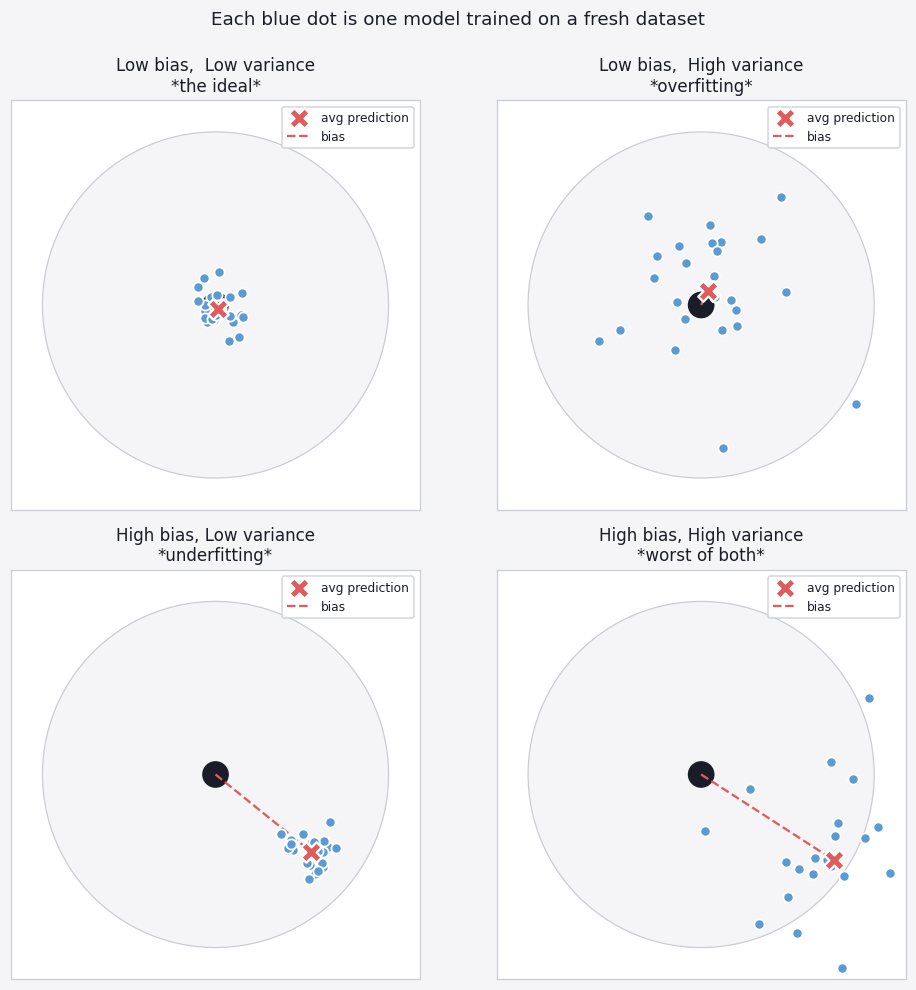

In [13]:
rng = np.random.RandomState(1)
n_shots = 25

def shots(bias_xy, var):
    return np.array(bias_xy) + var*rng.randn(n_shots, 2)

scenarios = [
    ('Low bias,  Low variance',  (0.0,  0.0), 0.10, '*the ideal*'),
    ('Low bias,  High variance', (0.0,  0.0), 0.45, '*overfitting*'),
    ('High bias, Low variance',  (0.6, -0.5), 0.10, '*underfitting*'),
    ('High bias, High variance', (0.6, -0.5), 0.45, '*worst of both*'),
]

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
for ax, (title, b, v, sub) in zip(axes.ravel(), scenarios):
    s = shots(b, v)
    # Concentric rings
    for r, c in zip([0.2, 0.5, 0.8, 1.1],
                    ['#fde7e7', '#fbd0d0', '#f7a8a8', '#f5f5f7']):
        ax.add_patch(plt.Circle((0, 0), r, color=c, ec='#c8ccd4', lw=0.8, zorder=0))
    ax.add_patch(plt.Circle((0, 0), 0.08, color='#1a1d27', zorder=1))   # bullseye
    # Arrows
    ax.scatter(s[:,0], s[:,1], color=PALETTE[0], s=45,
               edgecolor='white', linewidth=1.2, zorder=3)
    # Centre of the arrows = average prediction
    centre = s.mean(axis=0)
    ax.scatter(*centre, marker='X', s=180, color=PALETTE[1],
               edgecolor='white', linewidth=1.5, zorder=4,
               label='avg prediction')
    ax.plot([0, centre[0]], [0, centre[1]], color=PALETTE[1],
            ls='--', lw=1.5, zorder=2, label='bias')
    ax.set_xlim(-1.3, 1.3); ax.set_ylim(-1.3, 1.3)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'{title}\n{sub}', fontsize=11)
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('Each blue dot is one model trained on a fresh dataset', y=0.995)
plt.tight_layout(); plt.show()

- **Top-left** (low bias, low variance) — arrows cluster tightly *on* the bullseye. What we want.
- **Top-right** (low bias, high variance) — arrows still *average* to the bullseye, but any single shot can be far off. **Classic overfitting.**
- **Bottom-left** (high bias, low variance) — arrows cluster tightly, but *off* the bullseye. **Classic underfitting.**
- **Bottom-right** (high bias, high variance) — wrong on average *and* unstable. The worst.

Re-read the formula at the top with this picture in mind: $\text{bias}^2$ is the squared distance from the red X to the bullseye; variance is the spread of the blue dots around the red X.


---
## The classic schematic — bias, variance, total error vs complexity

Before we measure anything, here is the *picture* every textbook draws.
As model complexity grows:

- **Bias²** falls (the model can express more shapes).
- **Variance** rises (the model can also chase noise).
- **Total expected error = bias² + variance + irreducible noise** is U-shaped.

The sweet spot is the **minimum of the green curve**. Anything to its left is *underfitting*, anything to its right is *overfitting*.


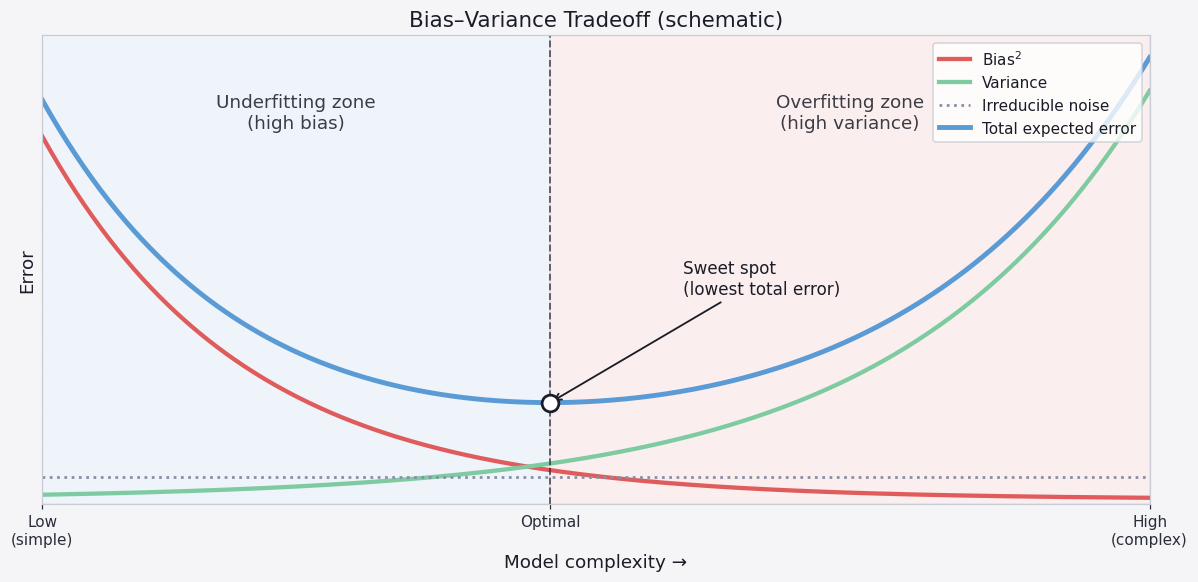

In [14]:
# Conceptual / schematic diagram — not measured, drawn from smooth curves.
c = np.linspace(0, 10, 400)
bias2     = 4.0 * np.exp(-0.55 * c) + 0.05
variance  = 0.05 * np.exp( 0.45 * c) + 0.05
irred     = np.full_like(c, 0.30)
total     = bias2 + variance + irred
opt_idx   = int(np.argmin(total))
opt_c     = c[opt_idx]

fig, ax = plt.subplots(figsize=(11, 5.4))

# Shaded zones
ax.axvspan(c[0],   opt_c, alpha=0.10, color=PALETTE[0], label='_nolegend_')
ax.axvspan(opt_c,  c[-1], alpha=0.10, color=PALETTE[1], label='_nolegend_')
ax.text(opt_c/2,        total.max()*0.92, 'Underfitting zone\n(high bias)',
        ha='center', va='top', fontsize=12, color='#1a1d27', alpha=0.85)
ax.text((opt_c+c[-1])/2, total.max()*0.92, 'Overfitting zone\n(high variance)',
        ha='center', va='top', fontsize=12, color='#1a1d27', alpha=0.85)

# Curves
ax.plot(c, bias2,    color=PALETTE[1], lw=2.8, label='Bias$^2$')
ax.plot(c, variance, color=PALETTE[3], lw=2.8, label='Variance')
ax.plot(c, irred,    color='#888fa5',  lw=1.8, ls=':', label='Irreducible noise')
ax.plot(c, total,    color=PALETTE[0], lw=3.2, label='Total expected error')

# Sweet-spot marker
ax.axvline(opt_c, color='#1a1d27', ls='--', lw=1.2, alpha=0.7)
ax.scatter([opt_c], [total[opt_idx]], color='white',
           edgecolor='#1a1d27', s=120, lw=1.8, zorder=6)
ax.annotate('Sweet spot\n(lowest total error)',
            xy=(opt_c, total[opt_idx]),
            xytext=(opt_c + 1.2, total[opt_idx] + 1.2),
            fontsize=11, ha='left',
            arrowprops=dict(arrowstyle='->', color='#1a1d27', lw=1.2))

ax.set_xlim(0, 10); ax.set_ylim(0, total.max()*1.05)
ax.set_xlabel('Model complexity →')
ax.set_ylabel('Error')
ax.set_xticks([0, opt_c, 10])
ax.set_xticklabels(['Low\n(simple)', 'Optimal', 'High\n(complex)'])
ax.set_yticks([])
ax.set_title('Bias–Variance Tradeoff (schematic)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Three model flexibilities on five fresh training sets

A flat (degree-1) model is rigid → high bias, low variance.
A wiggly (degree-15) model bends to noise → low bias, high variance.


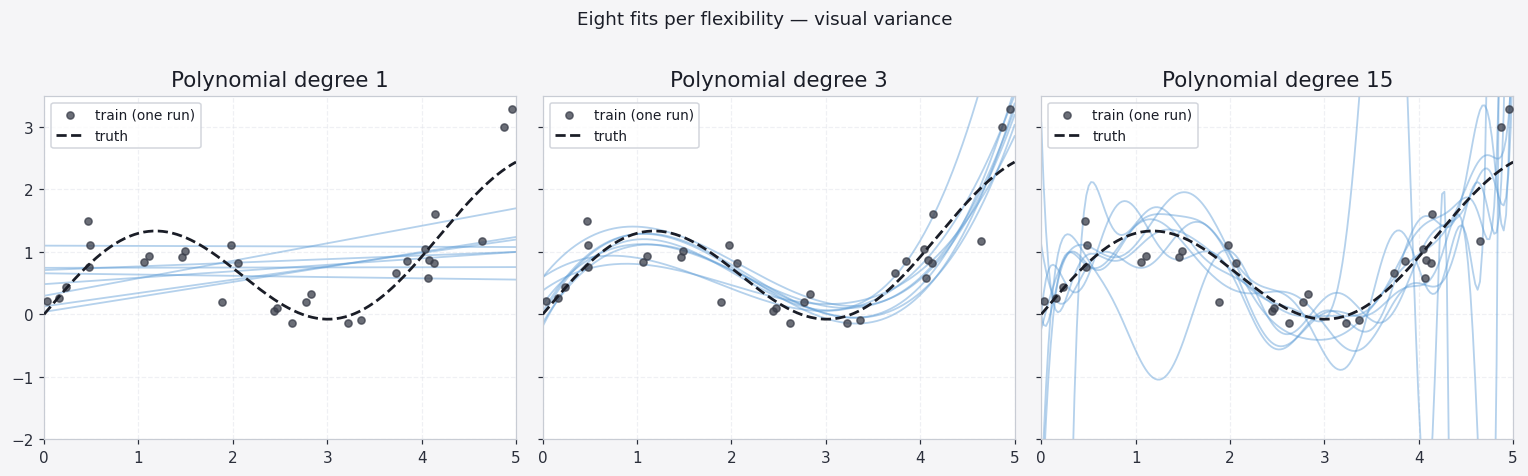

In [15]:
degrees = [1, 3, 15]
n_runs  = 50

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, d in zip(axes, degrees):
    for run in range(8):
        X, y = make_dataset(run)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X, y)
        ax.plot(x_test, m.predict(x_test[:, None]),
                color=PALETTE[0], alpha=0.45, lw=1.2)
    X, y = make_dataset(99)
    ax.scatter(X.ravel(), y, s=22, color='#3a3e4a', alpha=0.75,
               zorder=5, label='train (one run)')
    ax.plot(x_test, y_test_true, color='#1a1d27', lw=1.8, ls='--',
            zorder=6, label='truth')
    ax.set_title(f'Polynomial degree {d}')
    ax.set_xlim(0, 5)
    ax.grid(True); ax.legend(loc='upper left', fontsize=9)
axes[0].set_ylim(-2.0, 3.5)   # clip wild degree-15 extrapolations so all panels are readable
fig.suptitle('Eight fits per flexibility — visual variance', y=1.02)
fig.tight_layout(); plt.show()


---
## The classical U-shaped curve

Repeat the experiment over a range of polynomial degrees and 50 fresh training sets.
At each test point compute mean prediction (for bias²) and prediction variance.


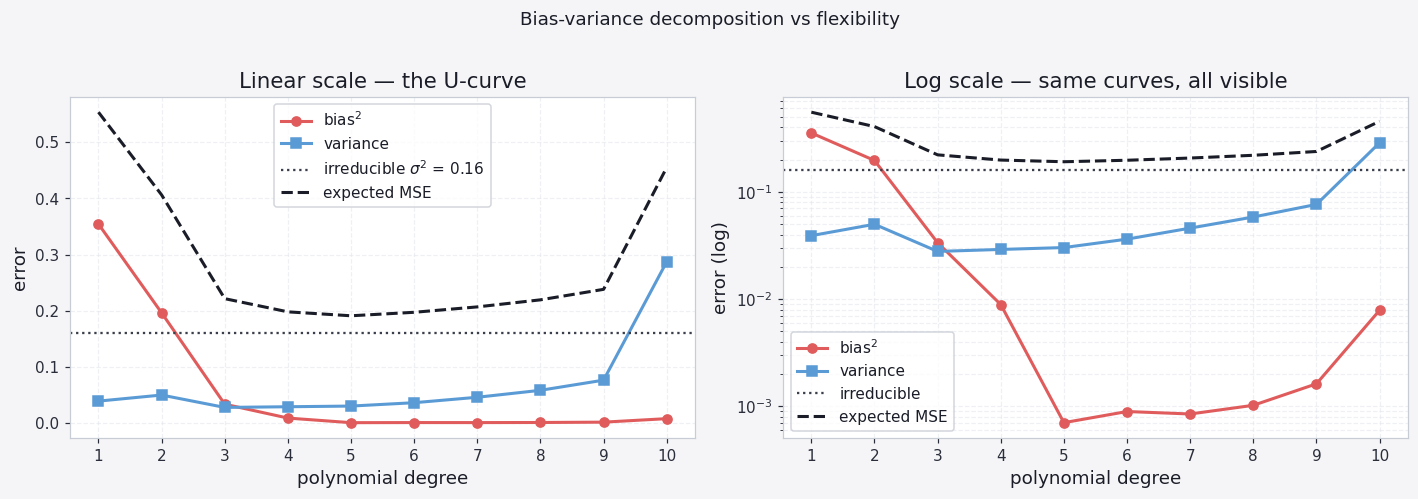

Lowest expected MSE at degree d = 5
  bias^2 at d=1  : 0.354   (high-bias regime)
  variance at d=1: 0.039
  bias^2 at d=5  : 0.001   (sweet spot)
  variance at d=5: 0.030
  bias^2 at d=10 : 0.008   (high-variance regime)
  variance at d=10: 0.287


In [16]:
degs = list(range(1, 11))   # degrees 11+ explode (variance ~10^6) and hide the trade-off
bias2, var, total = [], [], []
# Restrict evaluation to the *interior* of the training range so wild edge
# extrapolation from high-degree polynomials does not dominate the error bars.
mask = (x_test >= 0.5) & (x_test <= 4.5)
xt   = x_test[mask]
yt   = y_test_true[mask]

for d in degs:
    preds = np.zeros((n_runs, len(xt)))
    for run in range(n_runs):
        X, y = make_dataset(run)
        m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X, y)
        preds[run] = m.predict(xt[:, None])
    mean_pred = preds.mean(axis=0)
    bias2.append(np.mean((mean_pred - yt)**2))
    var.append(np.mean(preds.var(axis=0)))
    total.append(bias2[-1] + var[-1] + sigma**2)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# Linear scale — the classical U-curve
ax = axes[0]
ax.plot(degs, bias2, color=PALETTE[1], lw=2, marker='o', label='bias$^2$')
ax.plot(degs, var,   color=PALETTE[0], lw=2, marker='s', label='variance')
ax.axhline(sigma**2, color='#3a3e4a', ls=':', label=f'irreducible $\\sigma^2$ = {sigma**2:.2f}')
ax.plot(degs, total, color='#1a1d27', lw=2, ls='--', label='expected MSE')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('error')
ax.set_title('Linear scale — the U-curve'); ax.set_xticks(degs)
ax.legend(); ax.grid(True)

# Log scale — shows bias² collapse on the left
ax = axes[1]
ax.plot(degs, bias2, color=PALETTE[1], lw=2, marker='o', label='bias$^2$')
ax.plot(degs, var,   color=PALETTE[0], lw=2, marker='s', label='variance')
ax.axhline(sigma**2, color='#3a3e4a', ls=':', label='irreducible')
ax.plot(degs, total, color='#1a1d27', lw=2, ls='--', label='expected MSE')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('error (log)')
ax.set_title('Log scale — same curves, all visible'); ax.set_xticks(degs)
ax.legend(); ax.grid(True, which='both')

fig.suptitle('Bias-variance decomposition vs flexibility', y=1.02)
plt.tight_layout(); plt.show()

best = degs[int(np.argmin(total))]
print(f'Lowest expected MSE at degree d = {best}')
print(f'  bias^2 at d=1  : {bias2[0]:.3f}   (high-bias regime)')
print(f'  variance at d=1: {var[0]:.3f}')
print(f'  bias^2 at d={best}  : {bias2[best-1]:.3f}   (sweet spot)')
print(f'  variance at d={best}: {var[best-1]:.3f}')
print(f'  bias^2 at d=10 : {bias2[-1]:.3f}   (high-variance regime)')
print(f'  variance at d=10: {var[-1]:.3f}')


---
## Reading the curve

- **Left**: high bias, model can't bend enough to follow $f$.
- **Right**: low bias, but tiny perturbations in the training set move the fit dramatically — that's variance.
- The **sweet spot** in the middle minimises total error. It depends on $n$, $\sigma$, and the true $f$ — that is why **cross-validation** ([resampling tour](illustrated_00_foundations_resampling.ipynb)) is needed.

> Lesson: more flexibility helps **only** until the variance term overtakes the bias gain. There is no model that "doesn't overfit" — only models tuned to the right complexity for your data.


---
## Underfitting vs Overfitting — the train/test gap

The cleanest way to *diagnose* where you are on the curve:

- **Underfitting** = train error is high *and* test error is high (and similar).
- **Overfitting**  = train error is very low, test error is much higher (big gap).
- **Just right**   = both errors are low and close together.

Below: same data, three degrees. Watch how the train curve keeps dropping while the test curve eventually turns around.


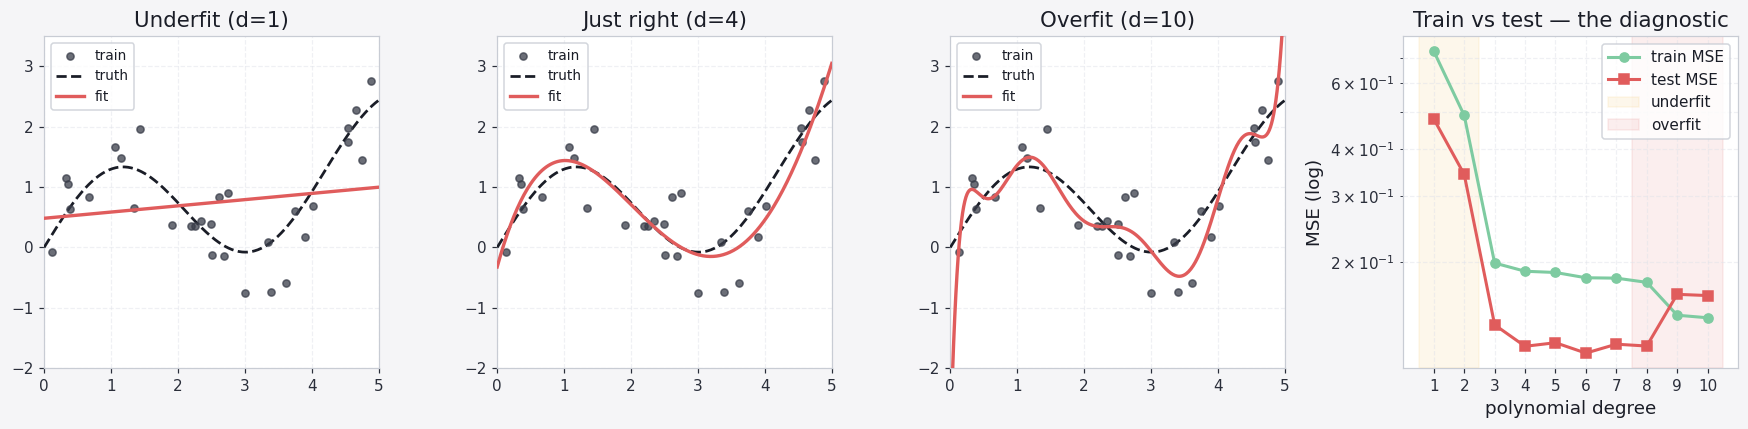

train MSE : ['0.727', '0.491', '0.199', '0.189', '0.187', '0.181', '0.181', '0.176', '0.144', '0.142']
test  MSE : ['0.480', '0.342', '0.136', '0.119', '0.122', '0.114', '0.121', '0.119', '0.164', '0.163']

Underfit (d=1):  train and test both high, gap small.
Just right (d=4): train and test both low, gap small.
Overfit (d=10): train near zero, test much larger - that gap IS overfitting.


In [17]:
from sklearn.metrics import mean_squared_error

X_train, y_train = make_dataset(7)
X_val,   y_val   = make_dataset(42)

train_err, val_err = [], []
fits = {}
for d in degs:
    m = make_pipeline(PolynomialFeatures(d), LinearRegression()).fit(X_train, y_train)
    train_err.append(mean_squared_error(y_train, m.predict(X_train)))
    val_err.append(  mean_squared_error(y_val,   m.predict(X_val)))
    if d in (1, 4, 10):
        fits[d] = m

fig, axes = plt.subplots(1, 4, figsize=(16, 4.0))
labels = {1: 'Underfit (d=1)', 4: 'Just right (d=4)', 10: 'Overfit (d=10)'}
xs = np.linspace(0, 5, 300)
for ax, d in zip(axes[:3], [1, 4, 10]):
    ax.scatter(X_train.ravel(), y_train, s=22, color='#3a3e4a',
               alpha=0.75, label='train', zorder=4)
    ax.plot(xs, f_true(xs), color='#1a1d27', lw=1.8, ls='--',
            label='truth', zorder=3)
    ax.plot(xs, fits[d].predict(xs[:, None]),
            color=PALETTE[1], lw=2.2, label='fit', zorder=5)
    ax.set_ylim(-2, 3.5); ax.set_xlim(0, 5)
    ax.set_title(labels[d]); ax.grid(True); ax.legend(loc='upper left', fontsize=9)

ax = axes[3]
ax.plot(degs, train_err, color=PALETTE[3], lw=2, marker='o', label='train MSE')
ax.plot(degs, val_err,   color=PALETTE[1], lw=2, marker='s', label='test MSE')
ax.set_yscale('log')
ax.set_xlabel('polynomial degree'); ax.set_ylabel('MSE (log)')
ax.set_title('Train vs test — the diagnostic'); ax.set_xticks(degs)
ax.axvspan(0.5, 2.5,  alpha=0.10, color=PALETTE[2], label='underfit')
ax.axvspan(7.5, 10.5, alpha=0.10, color=PALETTE[1], label='overfit')
ax.legend(); ax.grid(True, which='both')
plt.tight_layout(); plt.show()

print('train MSE :', [f'{e:.3f}' for e in train_err])
print('test  MSE :', [f'{e:.3f}' for e in val_err])
print()
print('Underfit (d=1):  train and test both high, gap small.')
print('Just right (d=4): train and test both low, gap small.')
print('Overfit (d=10): train near zero, test much larger - that gap IS overfitting.')
